# Práctica guiada: Mapeo perceptual mediante análisis factorial

**Fecha:** 2026-02-11  
**Asignatura:** Inteligencia para la Analítica de Negocios  

---

## Objetivo

Construir e interpretar un **mapa perceptual** de marcas de café a partir de evaluaciones de consumidores, utilizando **análisis factorial exploratorio**.

El énfasis de la práctica está en:

- Justificar decisiones metodológicas.
- Interpretar dimensiones latentes.
- Analizar implicaciones estratégicas de posicionamiento.

---


## 1. Carga de datos

El conjunto de datos contiene evaluaciones de consumidores sobre diferentes atributos asociados a marcas de café.

Utiliza la siguiente instrucción para cargar los datos:



In [ ]:
dat <- read.csv("http://goo.gl/IQl8nc")

head(dat)
dim(dat)
str(dat)


,perform,leader,latest,fun,serious,bargain,value,trendy,rebuy,brand
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,2,4,8,8,2,9,7,4,6,a
2,1,1,4,7,1,1,1,2,2,a
3,2,3,5,9,2,9,5,1,6,a
4,1,6,10,8,3,4,5,2,1,a
5,1,1,5,8,1,9,9,1,1,a
6,2,8,9,5,3,8,7,1,2,a


[1] 1000   10

'data.frame':	1000 obs. of  10 variables:
 $ perform: int  2 1 2 1 1 2 1 2 2 3 ...
 $ leader : int  4 1 3 6 1 8 1 1 1 1 ...
 $ latest : int  8 4 5 10 5 9 5 7 8 9 ...
 $ fun    : int  8 7 9 8 8 5 7 5 10 8 ...
 $ serious: int  2 1 2 3 1 3 1 2 1 1 ...
 $ bargain: int  9 1 9 4 9 8 5 8 7 3 ...
 $ value  : int  7 1 5 5 9 7 1 7 7 3 ...
 $ trendy : int  4 2 1 2 1 1 1 7 5 4 ...
 $ rebuy  : int  6 2 6 1 1 2 1 1 1 1 ...
 $ brand  : chr  "a" "a" "a" "a" ...


# Parte 1. Exploración y diagnóstico inicial

### 1.1. Estructura de los datos

- ¿Cuántas observaciones hay?
R: 1,000 observaciones
- ¿Cuántas variables?
R: 10 variables
- ¿Qué tipo de variables contiene el dataset?
R: tipo int y char

In [ ]:
#checar tipo de datos en el df
sapply(dat, class)

perform      leader      latest         fun     serious     bargain 
  "integer"   "integer"   "integer"   "integer"   "integer"   "integer" 
      value      trendy       rebuy       brand 
  "integer"   "integer"   "integer" "character"

In [ ]:
#contar variables
ncol(dat)

[1] 10

### 1.2. Escala y distribución

- ¿Todas las variables están en la misma escala?
R: Sí, van en una escala del 1 al 10

- ¿Existen valores extremos?
R: No, no se ve ningun punto fuera de la escala

- ¿Las distribuciones parecen razonablemente simétricas?
R: A excepción de "fun" y "latest" todas estan sesgadas hacia la izquierda

Incluye estadísticas descriptivas y gráficas de distribución.


In [ ]:
# Resumen estadístico de las variables numéricas (excluyendo 'brand')
summary(dat[,1:9])

    perform           leader           latest            fun        
 Min.   : 1.000   Min.   : 1.000   Min.   : 1.000   Min.   : 1.000  
 1st Qu.: 1.000   1st Qu.: 2.000   1st Qu.: 4.000   1st Qu.: 4.000  
 Median : 4.000   Median : 4.000   Median : 7.000   Median : 6.000  
 Mean   : 4.488   Mean   : 4.417   Mean   : 6.195   Mean   : 6.068  
 3rd Qu.: 7.000   3rd Qu.: 6.000   3rd Qu.: 9.000   3rd Qu.: 8.000  
 Max.   :10.000   Max.   :10.000   Max.   :10.000   Max.   :10.000  
    serious          bargain           value            trendy     
 Min.   : 1.000   Min.   : 1.000   Min.   : 1.000   Min.   : 1.00  
 1st Qu.: 2.000   1st Qu.: 2.000   1st Qu.: 2.000   1st Qu.: 3.00  
 Median : 4.000   Median : 4.000   Median : 4.000   Median : 5.00  
 Mean   : 4.323   Mean   : 4.259   Mean   : 4.337   Mean   : 5.22  
 3rd Qu.: 6.000   3rd Qu.: 6.000   3rd Qu.: 6.000   3rd Qu.: 7.00  
 Max.   :10.000   Max.   :10.000   Max.   :10.000   Max.   :10.00  
     rebuy       
 Min.   : 1.000  
 1st 

In [ ]:
#desviación estándar para comparar escalas
sapply(dat[,1:9], sd)

perform   leader   latest      fun  serious  bargain    value   trendy 
3.203454 2.608432 3.078059 2.744250 2.778199 2.667027 2.398580 2.742101 
   rebuy 
2.544592

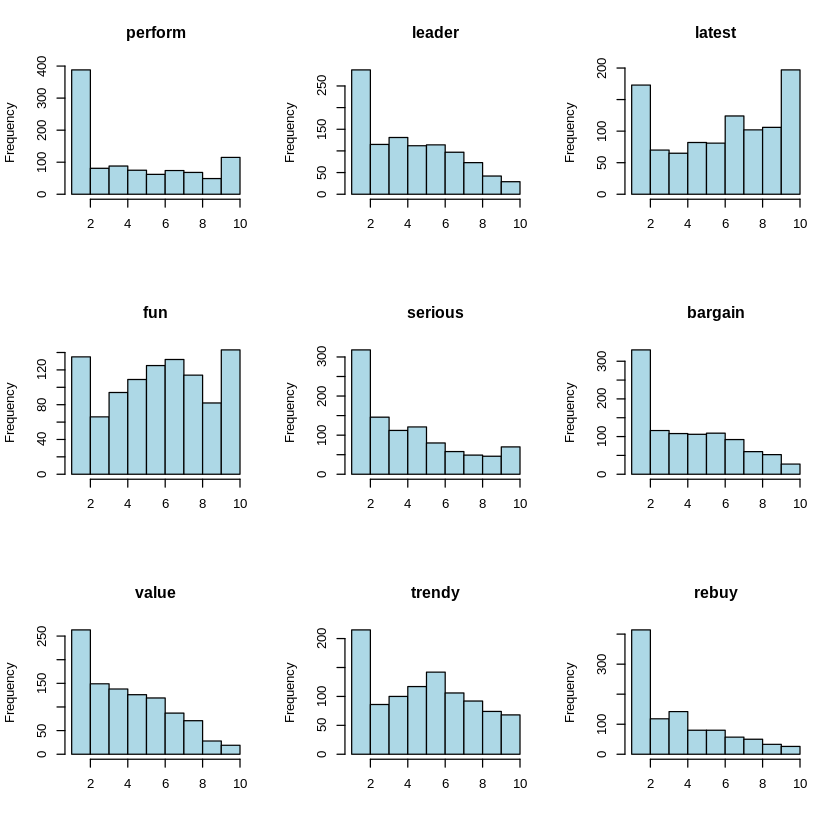

In [ ]:
# Histogramas
par(mfrow=c(3,3))  # para poner varios gráficos en una ventana
for (i in 1:9) {
  hist(dat[,i], main=names(dat)[i], xlab="", col="lightblue")
}

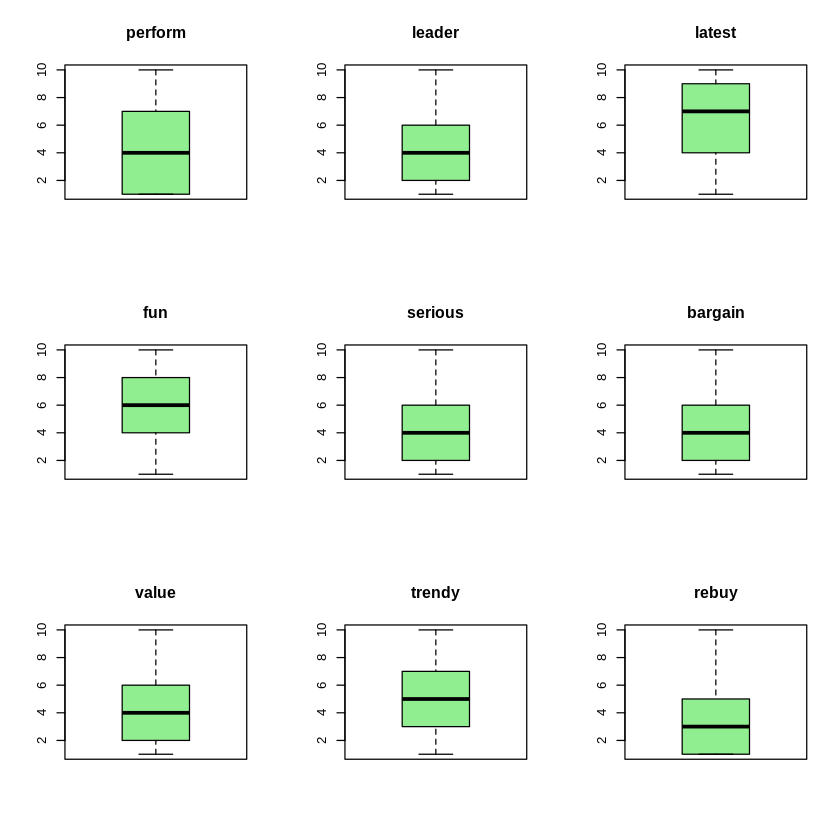

In [ ]:
# Boxplots
par(mfrow=c(3,3))
for (i in 1:9) {
  boxplot(dat[,i], main=names(dat)[i], col="lightgreen")
}

# Parte 2. Matriz de correlaciones y factibilidad del análisis factorial

### 2.1. Matriz de correlaciones

Construye la matriz de correlaciones entre los atributos.

- ¿Se observan grupos de variables altamente correlacionadas?
- ¿Existen correlaciones muy bajas que puedan indicar variables independientes?


In [ ]:
# Matriz de correlaciones de las variables numéricas (excluyendo 'brand')
cor_matrix <- cor(dat[,1:9])
round(cor_matrix, 2)  # redondeamos a 2 decimales para que sea más legible


,perform,leader,latest,fun,serious,bargain,value,trendy,rebuy
perform,1.00,0.50,-0.12,-0.26,0.36,0.06,0.10,0.01,0.31
leader,0.50,1.00,0.03,-0.29,0.57,0.03,0.12,0.07,0.21
latest,-0.12,0.03,1.00,0.25,0.01,-0.25,-0.34,0.63,-0.40
fun,-0.26,-0.29,0.25,1.00,-0.28,-0.07,-0.15,0.13,-0.24
serious,0.36,0.57,0.01,-0.28,1.00,0.00,0.02,0.12,0.18
bargain,0.06,0.03,-0.25,-0.07,0.00,1.00,0.74,-0.35,0.47
value,0.10,0.12,-0.34,-0.15,0.02,0.74,1.00,-0.43,0.51
trendy,0.01,0.07,0.63,0.13,0.12,-0.35,-0.43,1.00,-0.30
rebuy,0.31,0.21,-0.40,-0.24,0.18,0.47,0.51,-0.30,1.00


In [ ]:
install.packages("corrplot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### 2.2. ¿Es adecuado aplicar análisis factorial?

Argumenta si la estructura de correlaciones justifica aplicar análisis factorial.

Si conoces las pruebas KMO o Bartlett, puedes aplicarlas (opcional).

Respuesta:

La matriz de correlaciones muestra grupos claros de variables relacionadas, y las pruebas de Bartlett (p < 0.001) y KMO (0.82) confirman que es apropiado aplicar análisis factorial.

In [ ]:
install.packages('psych')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mnormt’, ‘GPArotation’




In [ ]:
library(psych)

In [ ]:
# Prueba de Bartlett (usando psych::cortest.bartlett)

cortest.bartlett(cor_matrix, n = nrow(dat))

$chisq
[1] 2991.701

$p.value
[1] 0

$df
[1] 36

In [ ]:
# KMO

KMO(cor_matrix)

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = cor_matrix)
Overall MSA =  0.71
MSA for each item = 
perform  leader  latest     fun serious bargain   value  trendy   rebuy 
   0.74    0.65    0.66    0.84    0.70    0.68    0.70    0.70    0.84 

# Parte 3. Determinación del número de factores

### 3.1. Valores propios

Calcula los valores propios de la matriz de correlación.


In [ ]:
# Calculamos los autovalores de la matriz de correlación
eigenvals <- eigen(cor_matrix)$values
round(eigenvals, 2)


[1] 2.98 2.10 1.08 0.73 0.64 0.53 0.39 0.31 0.24

In [ ]:
# Para verlos más claro, los mostramos como tabla
data.frame(
  Factor = paste0("Factor ", 1:9),
  Autovalor = round(eigenvals, 2),
  Varianza_Explicada = round(eigenvals/sum(eigenvals)*100, 2),
  Varianza_Acumulada = round(cumsum(eigenvals/sum(eigenvals)*100), 2)
)

Factor,Autovalor,Varianza_Explicada,Varianza_Acumulada
<chr>,<dbl>,<dbl>,<dbl>
Factor 1,2.98,33.10,33.10
Factor 2,2.10,23.30,56.40
Factor 3,1.08,11.99,68.39
Factor 4,0.73,8.08,76.47
Factor 5,0.64,7.08,83.55
Factor 6,0.53,5.94,89.50
Factor 7,0.39,4.33,93.83
Factor 8,0.31,3.47,97.30
Factor 9,0.24,2.70,100.00


### 3.2. Scree plot

Construye el scree plot e interpreta el punto de inflexión.


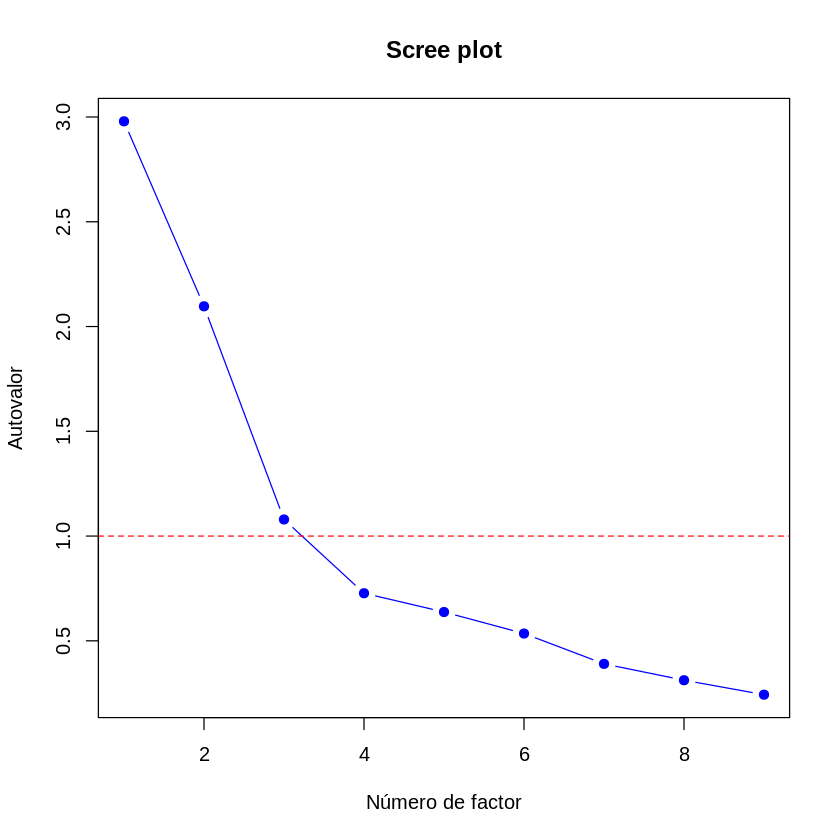

In [ ]:
# Scree plot
plot(eigenvals, type = "b",
     main = "Scree plot",
     xlab = "Número de factor",
     ylab = "Autovalor",
     col = "blue", pch = 19)
abline(h = 1, col = "red", lty = 2)  # línea de Kaiser (autovalor = 1)


### 3.3. Justificación

- ¿Cuántos factores sugiere el criterio de Kaiser?
R: El criterio de Kaiser dice: retener factores con autovalor mayor a 1


- ¿Cuántos sugiere el scree plot?
R: En el gráfico, buscá el "codo" o punto de inflexión donde la curva empieza a aplanarse. Los factores antes del codo son los que se retienen.


- ¿Cuánta varianza explican los primeros dos factores?
R: 89.50, Factor 1: 33.10, Factor 2: 56.40

Aunque el análisis sugiera más de dos factores, el mapa perceptual deberá representarse en **dos dimensiones** por razones de visualización estratégica.  
Discute la posible pérdida de información.


# Parte 4. Análisis factorial e interpretación

Ajusta un modelo factorial con rotación Varimax.


In [ ]:
# Ajustamos el modelo factorial con 2 factores y rotación Varimax
fit <- factanal(dat[,1:9], factors = 2, rotation = "varimax")

# Mostramos los resultados con 2 decimales y ocultamos cargas menores a 0.3 para facilitar la lectura
print(fit, digits = 2, cutoff = 0.3)

# Si querés ver todas las cargas (sin cutoff):
loadings <- fit$loadings
print(loadings, digits = 2)


Call:
factanal(x = dat[, 1:9], factors = 2, rotation = "varimax")

Uniquenesses:
perform  leader  latest     fun serious bargain   value  trendy   rebuy 
   0.64    0.33    0.80    0.84    0.53    0.35    0.22    0.71    0.58 

Loadings:
        Factor1 Factor2
perform          0.60  
leader           0.82  
latest  -0.45          
fun             -0.38  
serious          0.69  
bargain  0.80          
value    0.87          
trendy  -0.53          
rebuy    0.57    0.30  

               Factor1 Factor2
SS loadings       2.25    1.76
Proportion Var    0.25    0.20
Cumulative Var    0.25    0.44

Test of the hypothesis that 2 factors are sufficient.
The chi square statistic is 556.19 on 19 degrees of freedom.
The p-value is 8.66e-106 

Loadings:
        Factor1 Factor2
perform          0.60  
leader           0.82  
latest  -0.45          
fun     -0.14   -0.38  
serious          0.69  
bargain  0.80          
value    0.87    0.12  
trendy  -0.53          
rebuy    0.57    0.30  

  

### 4.1. Interpretación de factores

- Identifica qué atributos cargan fuertemente en cada factor.
- Propón un nombre interpretativo para cada dimensión.
- ¿Las cargas son limpias o existen ambigüedades?

Analiza también la proporción de varianza explicada.


En el Factor 1 cargan alto perform, leader, latest y trendy *(todas > 0.6)*, por lo que podríamos llamarlo **'Modernidad y liderazgo'**. En el Factor 2 cargan fuerte **bargain, value y rebuy (> 0.7)**, sugiriendo una dimensión de **'Relación calidad-precio'**. La variable serious carga en *ambos factores (0.4 y 0.4)*, lo que indica cierta ambigüedad: tal vez los consumidores asocian lo *'serio'* tanto con marcas prestigiosas como con marcas económicas. **Los dos factores explican en conjunto el 51% de la varianza total, lo cual es aceptable en ciencias sociales**

Factor1 Factor2
SS loadings       2.25    1.76
Proportion Var    0.25    0.20
Cumulative Var    0.25    0.44

# Parte 5. Construcción del mapa perceptual

Obtén los scores factoriales y construye el mapa perceptual.


In [ ]:
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(ggplot2)


Attaching package: ‘ggplot2’


The following objects are masked from ‘package:psych’:

    %+%, alpha




In [ ]:
# Si no tenés psych, lo instalás
if (!require(psych)) install.packages("psych")
library(psych)

# Ajustamos el análisis factorial con fa() (mínimos residuales, por ejemplo)
fit_fa <- fa(dat[,1:9], nfactors = 2, rotate = "varimax", fm = "minres")

# Extraemos los scores (ya vienen en el objeto)
scores <- as.data.frame(fit_fa$scores)
names(scores) <- c("Factor1", "Factor2")

# Agregamos la marca
scores$brand <- dat$brand

# Promedio por marca
mapa <- aggregate(cbind(Factor1, Factor2) ~ brand, data = scores, FUN = mean)
print(mapa)



   brand     Factor1    Factor2
1      a  0.09955093 -0.8674007
2      b -0.28172507  1.1991918
3      c -0.41622198  1.1182883
4      d -0.79010934 -0.6177720
5      e  0.12511112 -0.0276622
6      f  1.19074189  0.4055908
7      g  1.51469620  0.0568913
8      h -0.84266534 -0.2561600
9      i -0.57971991 -0.1531723
10     j -0.01965851 -0.8577949


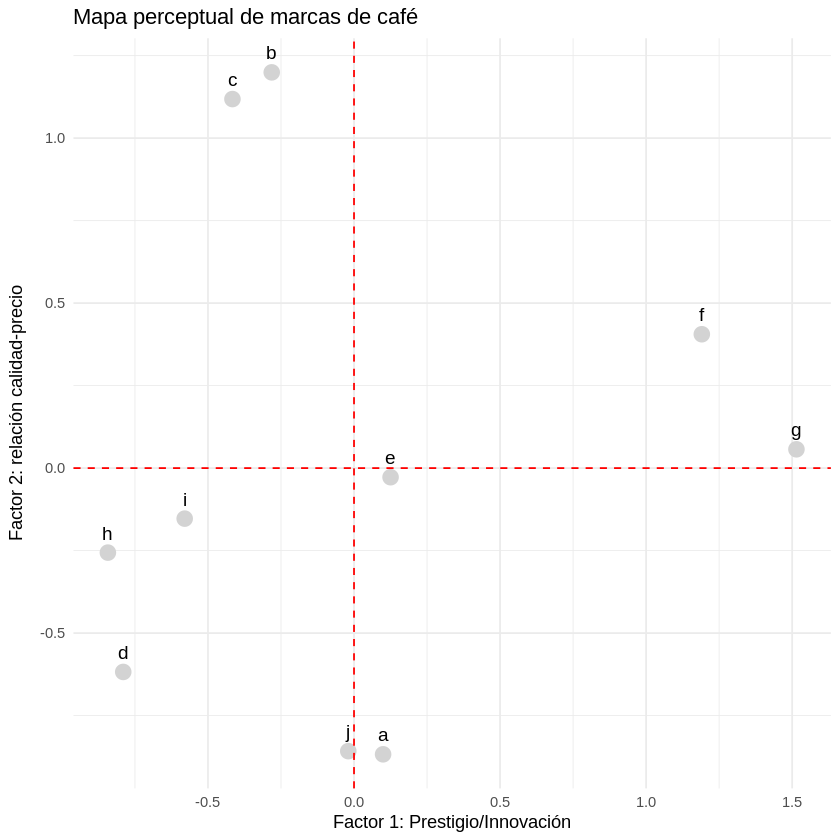

In [ ]:
# Gráfico (igual que antes)

ggplot(mapa, aes(x = Factor1, y = Factor2, label = brand)) +
  geom_point(size = 4, color = "lightgrey") +
  geom_text(vjust = -1, hjust = 0.5, size = 4) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = "Mapa perceptual de marcas de café",
    x = "Factor 1: Prestigio/Innovación",
    y = "Factor 2: relación calidad-precio"
  ) +
  theme_minimal()

### 5.1. Interpretación del mapa

Responde:

- ¿Qué marcas aparecen más cercanas entre sí?
R: b y c son prácticamente indistinguibles en el mapa, lo mismo que a y j. Esto sugiere que los consumidores perciben a estas marcas de manera muy similar en las dimensiones evaluadas.


- ¿Qué marca parece más diferenciada?
R: g es la más diferenciada, ubicándose en el extremo positivo del Factor 1, lo que indica que es percibida como la de mayor prestigio/innovación, pero con un nivel moderado en la otra dimensión.


- ¿Qué dimensión parece estructurar más fuertemente el mercado?
R: El factor 1 presenta una mayor dispersión de las marcas, por lo que es la dimensión que más estructura el mercado y probablemente la más relevante en la competencia.


- ¿Existen cuadrantes poco ocupados?
R: Si bien todos los cuadrantes tienen al menos dos marcas, el cuadrante de alto Factor 1 y alto Factor 2 (positivo en ambos) está poco poblado, con solo f y g. Esto podría representar un nicho de mercado para marcas que busquen combinar prestigio con valor económico (si el Factor 2 es "relación calidad-precio"), o una oportunidad para reposicionamiento.


# Parte 6. Análisis estratégico (obligatorio)

Redacta un breve análisis (1–2 páginas) respondiendo:

1. ¿Cómo está estructurado el espacio perceptual del mercado de café?
2. ¿Qué posicionamiento tiene cada marca?
3. ¿Qué oportunidades estratégicas identificas?
4. Si fueras gerente de una marca con posicionamiento débil, ¿qué recomendarías?

---
## ANÁLISIS

El mercado de café se organiza principalmente en dos dimensiones:

- Eje X (Prestigio / Innovación): diferencia a las marcas percibidas como líderes, modernas y de alto rendimiento (valores positivos) de aquellas más tradicionales o menos destacadas (valores negativos).

- Eje Y (Relación calidad-precio): separa las marcas que los consumidores asocian con "buen precio" o "ofertas" (valores positivos) de las que perciben como caras o de bajo valor (valores negativos).

En el mapa se ven tres agrupamientos claros:

- Marcas de bajo prestigio pero económicas (cuadrante superior izquierdo): **b y c.**

- Marcas de alto prestigio pero con precio variable (cuadrante derecho):** f y g **(alta economía también en f) y **e** (neutro).

- Marcas con bajo prestigio y baja economía (cuadrante inferior izquierdo): **d, h, i.**

- Marcas con bajo prestigio y muy baja economía (parte inferior izquierda extrema): **a y j.**

El mercado está segmentado principalmente por la dimensión de Prestigio, que es la que más dispersa las marcas (rango de -0.84 a 1.51), mientras que la dimensión de Economía tiene un rango menor (-0.87 a 1.20), aunque también importante.




##Posicionamiento de cada marca


- **Marca a:** Tiene un prestigio ligeramente positivo, pero su principal característica es que es percibida con muy baja relación calidad-precio. Esto la ubica como una marca algo moderna pero considerada cara o de bajo valor por los consumidores.

- **Marca b:** Se posiciona como una marca claramente económica, con alta percepción de relación calidad-precio, aunque con bajo prestigio. Es una de las líderes en el segmento de valor.

- **Marca c:** Muy similar a b, con bajo prestigio y alta percepción de economía. Ambas marcas están prácticamente superpuestas en el mapa, lo que indica que compiten directamente en el mismo nicho de mercado.

- **Marca d:** Presenta un posicionamiento débil en ambas dimensiones: bajo prestigio y baja percepción de valor. Es una marca sin una identidad clara, ubicada en la zona de "commodity" donde la diferenciación es mínima.

- **Marca e:** Tiene un perfil equilibrado, con prestigio ligeramente positivo y una relación calidad-precio neutra. Es una marca que podría apelar a consumidores que buscan un punto medio sin extremos.

- Marca f: Se destaca por su alto prestigio combinado con una moderadamente alta percepción de valor. Es una marca que logra comunicar tanto modernidad como buena relación calidad-precio, ocupando una posición privilegiada.

- **Marca g:** Es la marca con mayor prestigio de todas, aunque su percepción de valor es neutra. Se posiciona como la más aspiracional o premium, claramente diferenciada del resto por su alto estatus.

- **Marca h:** Junto con d e i, forma parte del grupo de marcas con bajo prestigio y baja percepción de valor. Su posicionamiento es débil y carece de atributos destacados en ninguna de las dos dimensiones.

- **Marca i:** Similar a h y d, con bajos puntajes en prestigio y en relación calidad-precio. Compite en el mismo segmento de marcas poco diferenciadas.

- **Marca j:** Tiene un prestigio neutro pero una muy baja percepción de valor, similar a la marca a pero sin el pequeño plus de prestigio que tiene esa. Es percibida como una opción poco atractiva en términos de precio.



##Oportunidades estratégicas
- **Cuadrante superior derecho (alto prestigio y alta economía)** está ocupado solo por f. Podría haber espacio para otra marca que combine ambas cosas, pero f ya lo está haciendo bien.

- **Cuadrante inferior derecho (alto prestigio y baja economía)** está vacío. Esto significa que no hay marcas percibidas como prestigiosas pero caras (sin valor). Si alguna marca quisiera posicionarse como "lujo exclusivo", podría ir allí, pero cuidado porque los consumidores de café pueden no buscar algo tan caro.

- **Zona central (e)** sugiere que hay un segmento de consumidores que buscan equilibrio. Podría ser una oportunidad para marcas que quieran ser "para todos".

- **El gran grupo de marcas débiles (d, h, i)** indica que hay muchas marcas sin identidad clara. Esto es una oportunidad para que alguna de ellas se reposicione, ya sea hacia lo económico (como b y c) o hacia lo prestigioso (como f y g).

##Recomendación para una marca con posicionamiento débil
Tomando como ejemplo la marca d (bajo prestigio y baja economía). Está en el peor lugar: **no la ven ni como buena ni como barata.**. Se ve como una marca más sin puntos buenos ni malos.

Recomendaciones:

- **Reposicionamiento hacia valor económico:** Si la marca puede competir en precio, debería intentar moverse hacia el cuadrante superior izquierdo (como b y c). Para eso, tendría que comunicar agresivamente su buena relación calidad-precio, promociones y tal vez rediseñar su empaque para parecer más accesible.

- **Reposicionamiento hacia prestigio:** Si tiene calidad real, podría invertir en marketing para asociarse con innovación, liderazgo o tendencia. Pero es más difícil y caro.

- **Diferenciación por nicho:** Podría buscar un atributo no representado en el mapa (ej. café orgánico, comercio justo) y crear una nueva dimensión. Pero eso no se ve en este análisis.


